<a href="https://colab.research.google.com/github/lauravazqx/Estocastic_simulation/blob/main/Tarea_2_SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 2. Simulación Estocástica.
## Laura T. Salvador Vazquez.

En esta sección se encontrarán los códigos necesarios implementados para la solución de los ejercicios de la Tarea 2 que lo hayan requerido.

# Problema 1.

In [3]:
import numpy as np
import matplotlib.pyplot as plt



In [6]:
np.percentile(X_pareto, 99)

np.float64(8.810199929100783)

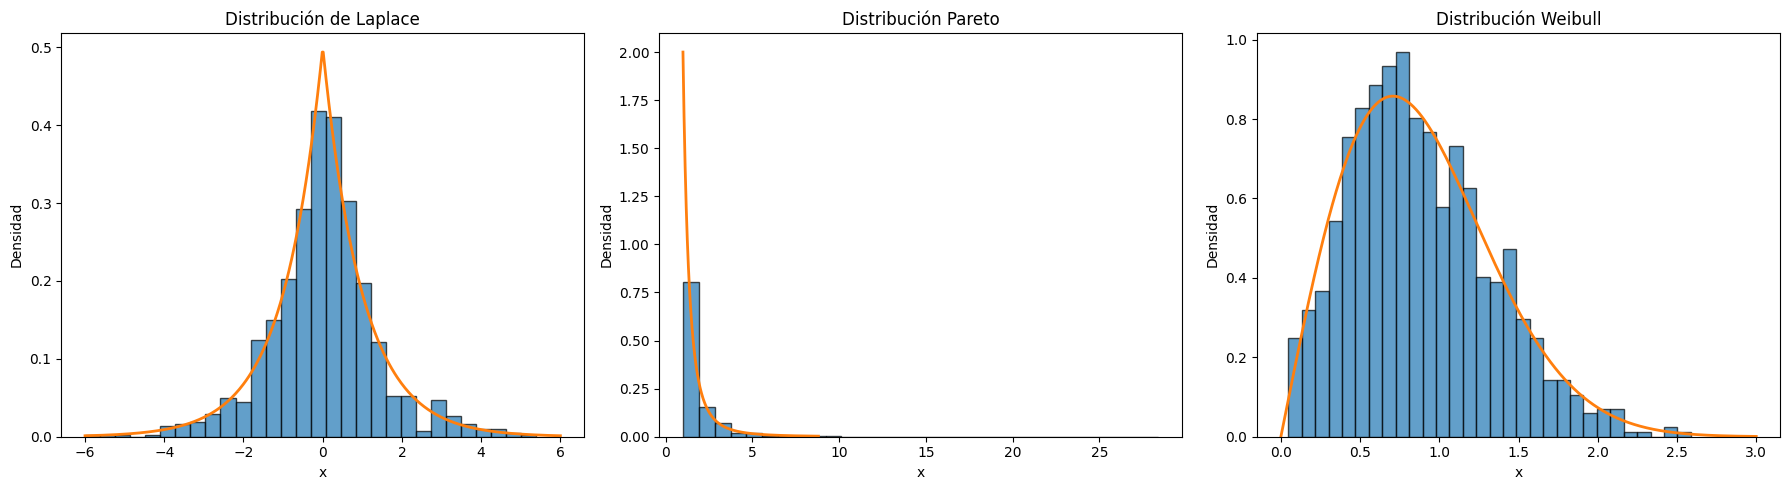

In [5]:

# Número de variables aleatorias
n = 1000

# Generación de números pseudoaleatorios U(0,1)
U = np.random.uniform(0, 1, n)

# =========================================================
# 1a. Distribución de Laplace
# =========================================================

mu = 0
b = 1

X_laplace = np.where(
    U < 0.5,
    mu + b * np.log(2 * U),
    mu - b * np.log(2 * (1 - U))
)

# =========================================================
# 1b. Distribución Pareto
# =========================================================

x0 = 1
alpha = 2

X_pareto = x0 * U ** (-1 / alpha)

# =========================================================
# 1c. Distribución Weibull
# =========================================================

k = 2
lam = 1

X_weibull = lam * (-np.log(U)) ** (1 / k)

# =========================================================
# Gráficas
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# Laplace
# ---------------------------------------------------------

axes[0].hist(
    X_laplace,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

x = np.linspace(-6, 6, 500)

f_laplace = (
    1 / (2 * b)
    * np.exp(-np.abs(x - mu) / b)
)

axes[0].plot(
    x,
    f_laplace,
    linewidth=2
)

axes[0].set_title("Distribución de Laplace")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Densidad")

# ---------------------------------------------------------
# Pareto
# ---------------------------------------------------------

axes[1].hist(
    X_pareto,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

x = np.linspace(x0, np.percentile(X_pareto, 99), 500)

f_pareto = (
    alpha * x0**alpha / x**(alpha + 1)
)

axes[1].plot(
    x,
    f_pareto,
    linewidth=2
)

axes[1].set_title("Distribución Pareto")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Densidad")

# ---------------------------------------------------------
# Weibull
# ---------------------------------------------------------

axes[2].hist(
    X_weibull,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

x = np.linspace(0, 3, 500)

f_weibull = (
    (k / lam)
    * (x / lam)**(k - 1)
    * np.exp(-(x / lam)**k)
)

axes[2].plot(
    x,
    f_weibull,
    linewidth=2
)

axes[2].set_title("Distribución Weibull")
axes[2].set_xlabel("x")
axes[2].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

# Problema 4.

In [2]:
np.random.seed(123)

Primeras 10 variables simuladas:
[-1.0856306   1.17582904  0.9071052  -1.4286807  -0.25561937 -2.79858911
 -0.17363568  0.28362732 -0.39089979  2.39236527]

Número de variables simuladas: 1000


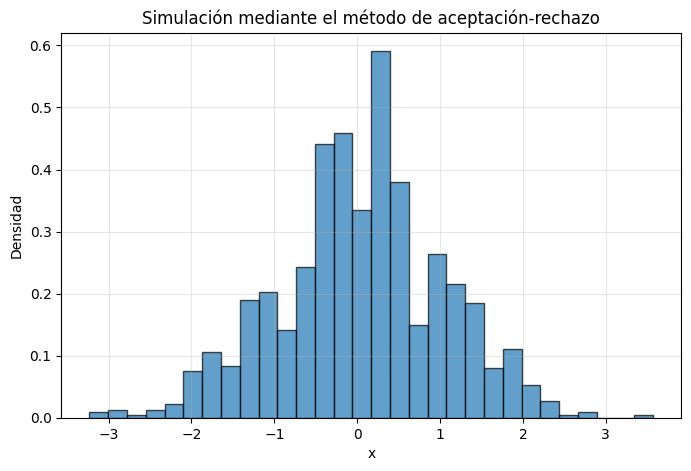

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para obtener los mismos resultados cada vez
np.random.seed(123)

# Número de variables aleatorias que queremos generar
n = 1000

# Lista para guardar las variables aceptadas
muestras = []

# Algoritmo de aceptación-rechazo
while len(muestras) < n:

    # Paso 1: generar Y ~ N(0,1)
    y = np.random.normal(0, 1)

    # Paso 2: generar U ~ U(0,1)
    u = np.random.uniform(0, 1)

    # Paso 3: calcular la probabilidad de aceptación
    prob_aceptacion = (
        0.5 * np.sin(8 * y)**2
        + 2 * np.cos(2 * y)**2 * np.sin(4 * y)**2
        + 0.5
    ) / 3

    # Paso 4: aceptar o rechazar
    if u <= prob_aceptacion:
        muestras.append(y)

# Convertir la lista a un arreglo de NumPy
muestras = np.array(muestras)

# Mostrar las primeras 10 observaciones
print("Primeras 10 variables simuladas:")
print(muestras[:10])

# Mostrar el número total de variables generadas
print("\nNúmero de variables simuladas:", len(muestras))

# Histograma
plt.figure(figsize=(8, 5))

plt.hist(
    muestras,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Simulación mediante el método de aceptación-rechazo")
plt.grid(alpha=0.3)

plt.show()

Constante de normalización C = 3.1334955633160977
Error de integración = 4.322205974528922e-09


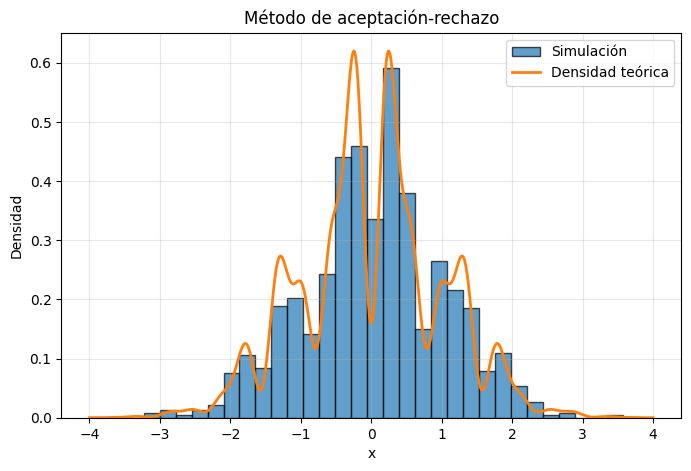

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --------------------------------------------------
# 1. Definir la función de densidad no normalizada
# --------------------------------------------------

def fk(x):
    return np.exp(-x**2 / 2) * (
        0.5 * np.sin(8 * x)**2
        + 2 * np.cos(2 * x)**2 * np.sin(4 * x)**2
        + 0.5
    )


# --------------------------------------------------
# 2. Calcular la constante de normalización
# --------------------------------------------------

C, error = quad(fk, -np.inf, np.inf)

print("Constante de normalización C =", C)
print("Error de integración =", error)


# --------------------------------------------------
# 3. Crear los valores de x para la gráfica
# --------------------------------------------------

x = np.linspace(-4, 4, 1000)


# --------------------------------------------------
# 4. Calcular la densidad normalizada
# --------------------------------------------------

densidad = fk(x) / C


# --------------------------------------------------
# 5. Graficar histograma y densidad teórica
# --------------------------------------------------

plt.figure(figsize=(8, 5))

# Histograma de las variables simuladas
plt.hist(
    muestras,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulación"
)

# Densidad teórica
plt.plot(
    x,
    densidad,
    linewidth=2,
    label="Densidad teórica"
)

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Método de aceptación-rechazo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()